<a href="https://colab.research.google.com/github/Cd881/CSCI164/blob/main/164_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import math
import gdown
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
#https://www.kaggle.com/datasets/adilshamim8/student-depression-dataset
#https://drive.google.com/file/d/1UKvAX8DyU9RwH70vFF8dAIZYPebJ3VrL/view?usp=drive_link
gdown.download(id='1UKvAX8DyU9RwH70vFF8dAIZYPebJ3VrL', output='StudentDepressionData.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1UKvAX8DyU9RwH70vFF8dAIZYPebJ3VrL
To: /content/StudentDepressionData.csv
100%|██████████| 2.90M/2.90M [00:00<00:00, 41.1MB/s]


'StudentDepressionData.csv'

In [ ]:
#https://www.kaggle.com/datasets/spscientist/students-performance-in-exams/data
#https://drive.google.com/file/d/1c0BOCNbDtNESZ5rOAaM88GX2MC_FLZKt/view?usp=sharing
gdown.download(id='1c0BOCNbDtNESZ5rOAaM88GX2MC_FLZKt', output='StudentPerformanceData.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1c0BOCNbDtNESZ5rOAaM88GX2MC_FLZKt
To: /content/StudentPerformanceData.csv
100%|██████████| 72.0k/72.0k [00:00<00:00, 64.8MB/s]


'StudentPerformanceData.csv'

In [ ]:
#https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who
#https://drive.google.com/file/d/1VMFY2aYS0SAkeBtGOioRapptUmG9IV9u/view?usp=sharing
gdown.download(id='1VMFY2aYS0SAkeBtGOioRapptUmG9IV9u', output='LifeExpectancyData.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1VMFY2aYS0SAkeBtGOioRapptUmG9IV9u
To: /content/LifeExpectancyData.csv
100%|██████████| 333k/333k [00:00<00:00, 51.6MB/s]


'LifeExpectancyData.csv'

# **Dataset One:** Student Depression😞

In [ ]:
student_data = pd.read_csv("/content/StudentDepressionData.csv")

print("Original data:")
print(student_data.head())
print("Missing values before preprocessing:\n", student_data.isna().sum())
#student_data.head()

Original data:
   id  Gender   Age           City Profession  Academic Pressure  \
0   2    Male  33.0  Visakhapatnam    Student                5.0   
1   8  Female  24.0      Bangalore    Student                2.0   
2  26    Male  31.0       Srinagar    Student                3.0   
3  30  Female  28.0       Varanasi    Student                3.0   
4  32  Female  25.0         Jaipur    Student                4.0   

   Work Pressure  CGPA  Study Satisfaction  Job Satisfaction  \
0            0.0  8.97                 2.0               0.0   
1            0.0  5.90                 5.0               0.0   
2            0.0  7.03                 5.0               0.0   
3            0.0  5.59                 2.0               0.0   
4            0.0  8.13                 3.0               0.0   

        Sleep Duration Dietary Habits   Degree  \
0          '5-6 hours'        Healthy  B.Pharm   
1          '5-6 hours'       Moderate      BSc   
2  'Less than 5 hours'        Healthy    

**Preprocessing**

In [ ]:
unwanted_cols = ['id', 'Gender', 'City', 'Profession', 'Degree']

binary_cols = ['Have you ever had suicidal thoughts ?',
               'Family History of Mental Illness']

cat_cols = ['Dietary Habits']

# Drop unwanted features
student_data.drop(unwanted_cols, axis=1, inplace=True)

# Map the categories to numerical values
sleep_map = {
    '\'Less than 5 hours\'': 4,
    '\'5-6 hours\'': 5.5,
    '\'7-8 hours\'': 7.5,
    '\'More than 8 hours\'': 9,
    '\'Others\'': 10
}
student_data['Sleep Duration'] = student_data['Sleep Duration'].map(sleep_map)
# Fill missing values
most_common_sleep = student_data['Sleep Duration'].mode()[0]  # Get the most frequent value
student_data['Sleep Duration'] = student_data['Sleep Duration'].fillna(most_common_sleep)
stress_map = {
    '0.0': 0,
    '1.0': 1,
    '2.0': 2,
    '3.0': 3,
    '4.0': 4,
    '5.0': 5
}
student_data['Financial Stress'] = student_data['Financial Stress'].map(stress_map)
most_common_stress = student_data['Financial Stress'].mode()[0]
student_data['Financial Stress'] = student_data['Financial Stress'].fillna(most_common_stress)
# Change the yes and no questions to bool
for col in binary_cols:
    student_data[col] = student_data[col].map({'Yes': True, 'No': False})
# Output to bool
student_data['Depression'] = student_data['Depression'].map({1: True, 0: False})

# One-Hot encoding for the category cols
student_data = pd.get_dummies(student_data, columns=cat_cols, drop_first=True)

# Standardize
numeric_cols = student_data.select_dtypes(include=np.number).columns
scaler = StandardScaler()
student_data[numeric_cols] = scaler.fit_transform(student_data[numeric_cols])

print("Missing values after preprocessing:\n", student_data.isna().sum())
print(student_data.head())
#student_data.head()

Missing values after preprocessing:
 Age                                      0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
Dietary Habits_Moderate                  0
Dietary Habits_Others                    0
Dietary Habits_Unhealthy                 0
dtype: int64
        Age  Academic Pressure  Work Pressure      CGPA  Study Satisfaction  \
0  1.463165           1.345543      -0.009777  0.893393           -0.693425   
1 -0.371474          -0.826104      -0.009777 -1.194076            1.510636   
2  1.055467          -0.102222      -0.009777 -0.425724            1

**Model Building**

In [ ]:
X = student_data.drop('Depression', axis=1)
y = student_data['Depression']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (22320, 14)
Test shape: (5581, 14)


**Logistic Regression**

In [ ]:
log = LogisticRegression(max_iter=1000)
log.fit(X_train, y_train)

y_pred1_before = log.predict(X_test)

print("Classification Report - Logistic Regression:")
report1_before = classification_report(y_test, y_pred1_before, output_dict=True) #used for comparison
print(classification_report(y_test, y_pred1_before))

Classification Report - Logistic Regression:
              precision    recall  f1-score   support

       False       0.82      0.78      0.80      2343
        True       0.85      0.88      0.86      3238

    accuracy                           0.84      5581
   macro avg       0.83      0.83      0.83      5581
weighted avg       0.84      0.84      0.84      5581



<Figure size 600x400 with 0 Axes>

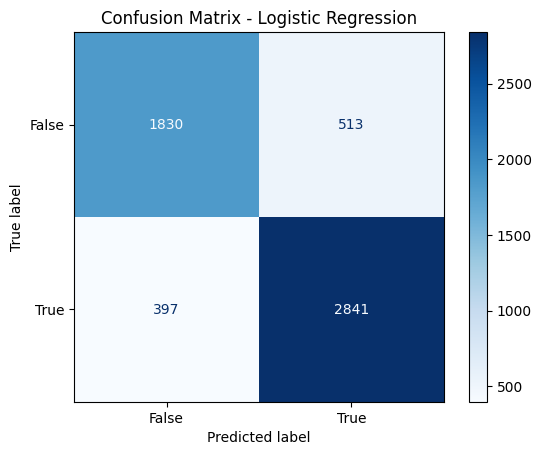

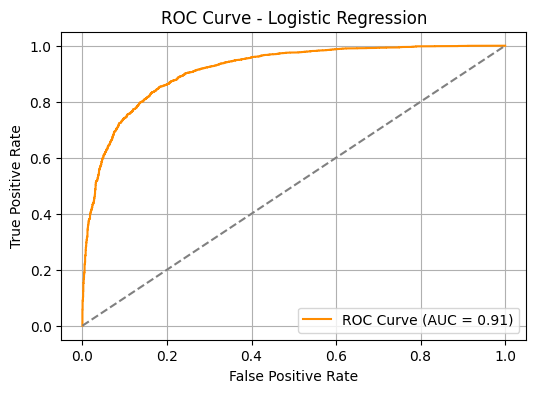

In [ ]:
# Confusion Maxtrix
plt.figure(figsize=(6, 4))
cm = ConfusionMatrixDisplay.from_estimator(log, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.grid(False)
plt.show()

# ROC curve
y_proba1_before = log.predict_proba(X_test)[:, 1]
fpr_log, tpr_log, thresholds = roc_curve(y_test, y_proba1_before)
roc_auc1b = auc(fpr_log, tpr_log)

plt.figure(figsize=(6, 4))
plt.plot(fpr_log, tpr_log, label=f'ROC Curve (AUC = {roc_auc1b:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Tuning

In [ ]:
# Parameter grid for tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs']
}

logreg = LogisticRegression(max_iter=1000)
grid = GridSearchCV(logreg, param_grid, cv=5, scoring='accuracy',
                    return_train_score=True)
grid.fit(X_train, y_train)

best_logreg = grid.best_estimator_
y_pred1 = best_logreg.predict(X_test)

# Classification report
print("Best Parameters:", grid.best_params_)
report1 = classification_report(y_test, y_pred1, output_dict=True) #used for comparison later
temp = classification_report(y_test, y_pred1)
print("Classification Report - Tuned Logistic Regression:\n", temp)

print("Best Cross-Validation Accuracy:", grid.best_score_)

cv_results = pd.DataFrame(grid.cv_results_)
display(cv_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values('rank_test_score'))

Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Classification Report - Tuned Logistic Regression:
               precision    recall  f1-score   support

       False       0.82      0.78      0.80      2343
        True       0.85      0.88      0.86      3238

    accuracy                           0.84      5581
   macro avg       0.83      0.83      0.83      5581
weighted avg       0.84      0.84      0.84      5581

Best Cross-Validation Accuracy: 0.8489247311827958


,params,mean_test_score,std_test_score,rank_test_score
5,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.848925,0.002793,1
4,"{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}",0.848835,0.002839,2
7,"{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}",0.848835,0.002824,2
9,"{'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}",0.848835,0.002824,2
8,"{'C': 100, 'penalty': 'l2', 'solver': 'libline...",0.848790,0.002948,5
6,"{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}",0.848790,0.002948,5
3,"{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.848701,0.002444,7
2,"{'C': 0.1, 'penalty': 'l2', 'solver': 'libline...",0.848611,0.002867,8
1,"{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}",0.848566,0.003025,9
0,"{'C': 0.01, 'penalty': 'l2', 'solver': 'liblin...",0.847536,0.002549,10


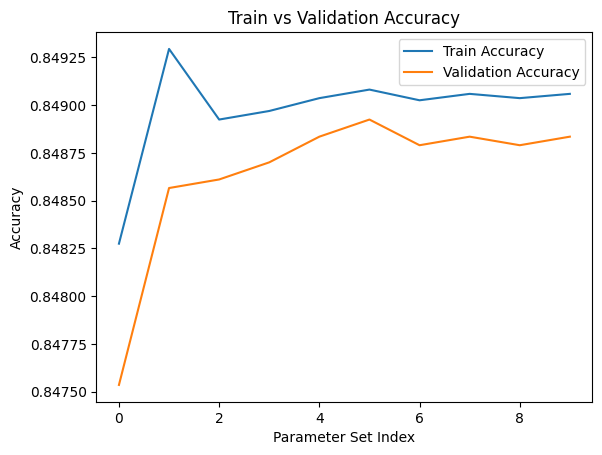

In [ ]:
plt.plot(cv_results["mean_train_score"], label="Train Accuracy")
plt.plot(cv_results["mean_test_score"], label="Validation Accuracy")
plt.legend()
plt.title("Train vs Validation Accuracy")
plt.xlabel("Parameter Set Index")
plt.ylabel("Accuracy")
plt.show()

<Figure size 600x400 with 0 Axes>

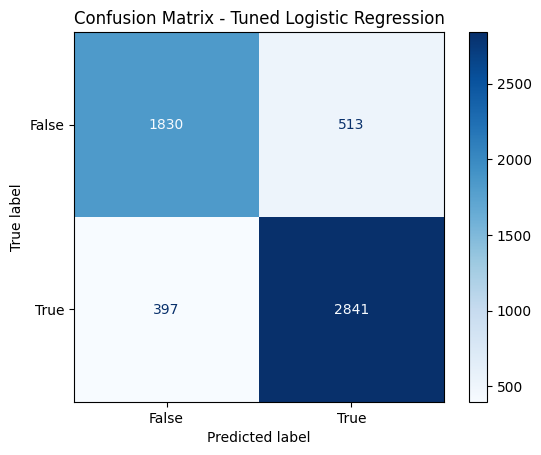

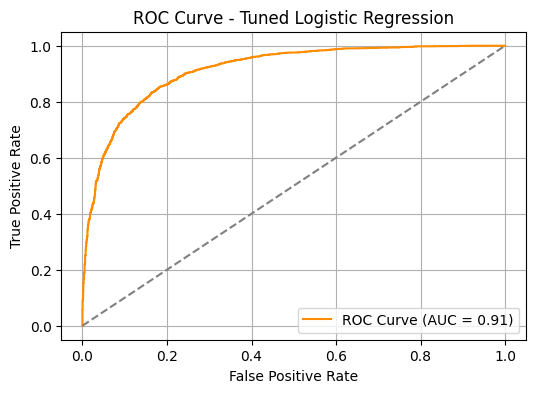

In [ ]:
# Confusion Maxtrix
plt.figure(figsize=(6, 4))
cm = ConfusionMatrixDisplay.from_estimator(best_logreg, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.grid(False)
plt.show()

# ROC curve
y_proba1 = best_logreg.predict_proba(X_test)[:, 1]
fpr_log, tpr_log, thresholds = roc_curve(y_test, y_proba1)
roc_auc1 = auc(fpr_log, tpr_log)

plt.figure(figsize=(6, 4))
plt.plot(fpr_log, tpr_log, label=f'ROC Curve (AUC = {roc_auc1:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**K-Nearest Neighbors**

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred2_before = knn.predict(X_test)

print("Classification Report - K-Nearest Neighbors:")
report2_before = classification_report(y_test, y_pred2_before, output_dict=True)
print(classification_report(y_test, y_pred2_before))

Classification Report - K-Nearest Neighbors:
              precision    recall  f1-score   support

       False       0.81      0.75      0.78      2343
        True       0.83      0.87      0.85      3238

    accuracy                           0.82      5581
   macro avg       0.82      0.81      0.81      5581
weighted avg       0.82      0.82      0.82      5581



<Figure size 600x400 with 0 Axes>

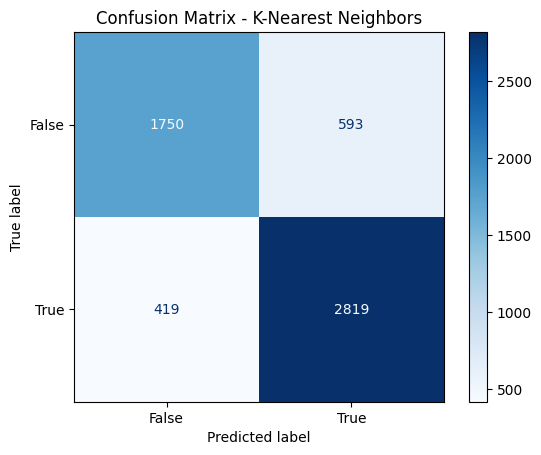

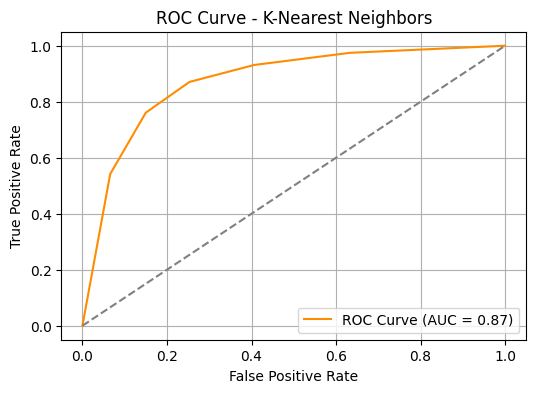

In [ ]:
# Confusion Maxtrix
plt.figure(figsize=(6, 4))
cm = ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix - K-Nearest Neighbors")
plt.grid(False)
plt.show()

#ROC Curve
y_proba2_before = knn.predict_proba(X_test)[:, 1]
fpr_knn, tpr_knn, thresholds = roc_curve(y_test, y_proba2_before)
roc_auc2b = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(6, 4))
plt.plot(fpr_knn, tpr_knn, label=f'ROC Curve (AUC = {roc_auc2b:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - K-Nearest Neighbors")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Tuning

In [ ]:
knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [5, 25, 29, 35, 39, 45]
}

grid_search_knn = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy',
                               n_jobs=-1, return_train_score=True)
grid_search_knn.fit(X_train, y_train)

print("Best Parameters:", grid_search_knn.best_params_)
best_knn = grid_search_knn.best_estimator_

y_pred2 = best_knn.predict(X_test)
print("Best Parameters:", grid.best_params_)
print("Classification Report - Tuned K-Nearest Neighbors:")
report2 = classification_report(y_test, y_pred2, output_dict=True)
print(classification_report(y_test, y_pred2))

print("Best Cross-Validation Accuracy:", grid.best_score_)

cv_results = pd.DataFrame(grid.cv_results_)
display(cv_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values('rank_test_score'))

Best Parameters: {'n_neighbors': 29}
Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Classification Report - Tuned K-Nearest Neighbors:
              precision    recall  f1-score   support

       False       0.83      0.74      0.78      2343
        True       0.83      0.89      0.86      3238

    accuracy                           0.83      5581
   macro avg       0.83      0.82      0.82      5581
weighted avg       0.83      0.83      0.83      5581

Best Cross-Validation Accuracy: 0.8489247311827958


,params,mean_test_score,std_test_score,rank_test_score
5,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.848925,0.002793,1
4,"{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}",0.848835,0.002839,2
7,"{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}",0.848835,0.002824,2
9,"{'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}",0.848835,0.002824,2
8,"{'C': 100, 'penalty': 'l2', 'solver': 'libline...",0.848790,0.002948,5
6,"{'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}",0.848790,0.002948,5
3,"{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.848701,0.002444,7
2,"{'C': 0.1, 'penalty': 'l2', 'solver': 'libline...",0.848611,0.002867,8
1,"{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}",0.848566,0.003025,9
0,"{'C': 0.01, 'penalty': 'l2', 'solver': 'liblin...",0.847536,0.002549,10


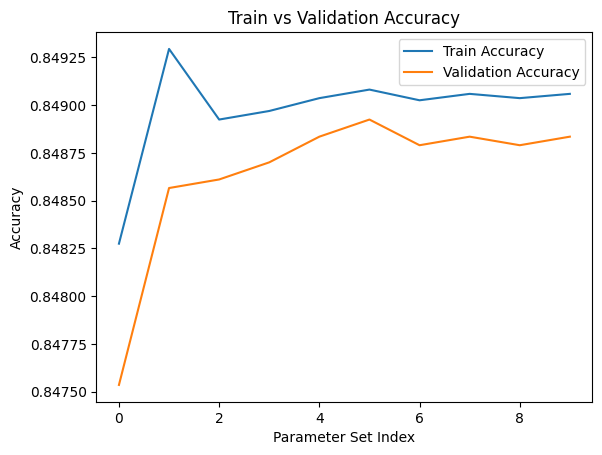

In [ ]:
plt.plot(cv_results["mean_train_score"], label="Train Accuracy")
plt.plot(cv_results["mean_test_score"], label="Validation Accuracy")
plt.legend()
plt.title("Train vs Validation Accuracy")
plt.xlabel("Parameter Set Index")
plt.ylabel("Accuracy")
plt.show()

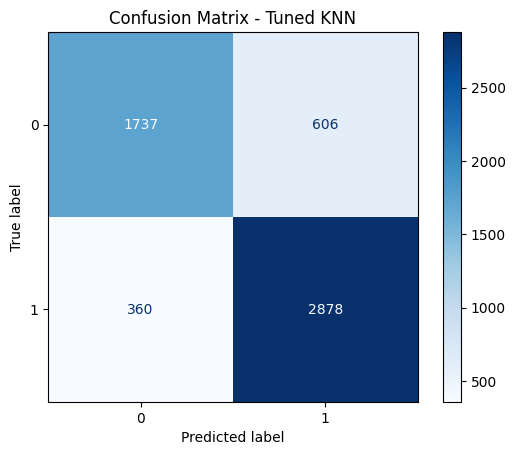

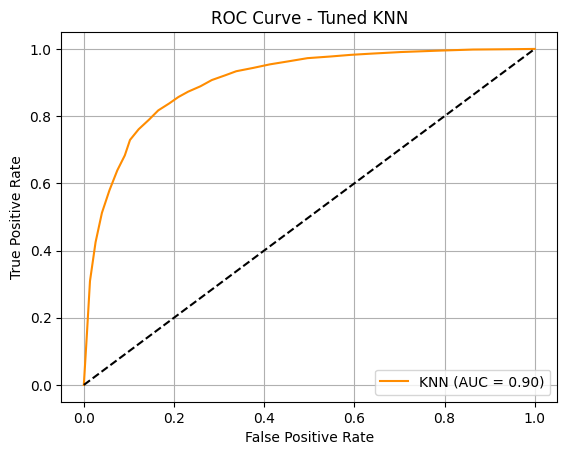

In [ ]:
cm = confusion_matrix(y_test, y_pred2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Tuned KNN")
plt.show()

y_proba2 = best_knn.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba2)
roc_auc2 = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"KNN (AUC = {roc_auc2:.2f})", color='darkorange')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned KNN")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Multi-Layer Perceptron**

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

y_pred3_before = mlp.predict(X_test)

print("Classification Report - Multi-Layer Perceptron:")
report3_before = classification_report(y_test, y_pred3_before, output_dict=True)
print(classification_report(y_test, y_pred3_before))

Classification Report - Multi-Layer Perceptron:
              precision    recall  f1-score   support

       False       0.81      0.80      0.80      2343
        True       0.86      0.86      0.86      3238

    accuracy                           0.83      5581
   macro avg       0.83      0.83      0.83      5581
weighted avg       0.83      0.83      0.83      5581



<Figure size 600x400 with 0 Axes>

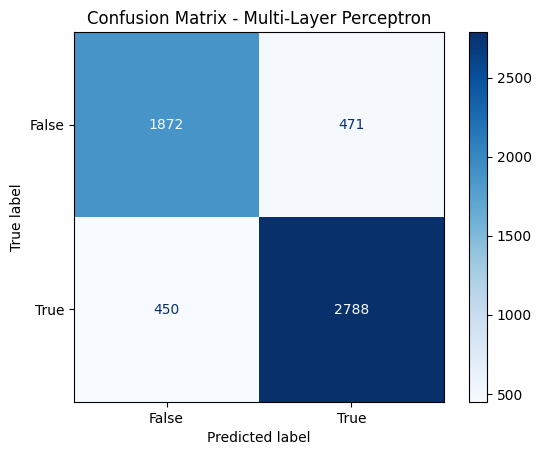

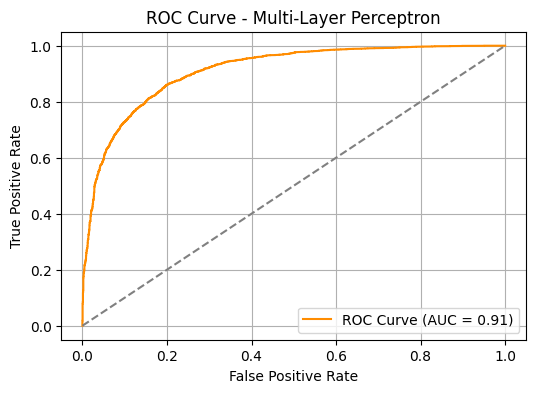

In [ ]:
# Confusion Matrix
plt.figure(figsize=(6, 4))
cm = ConfusionMatrixDisplay.from_estimator(mlp, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix - Multi-Layer Perceptron")
plt.grid(False)
plt.show()

# ROC Curve
y_proba3_before = mlp.predict_proba(X_test)[:, 1]
fpr_mlp, tpr_mlp, thresholds = roc_curve(y_test, y_proba3_before)
roc_auc3b = auc(fpr_mlp, tpr_mlp)

plt.figure(figsize=(6, 4))
plt.plot(fpr_mlp, tpr_mlp, label=f'ROC Curve (AUC = {roc_auc3b:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multi-Layer Perceptron")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

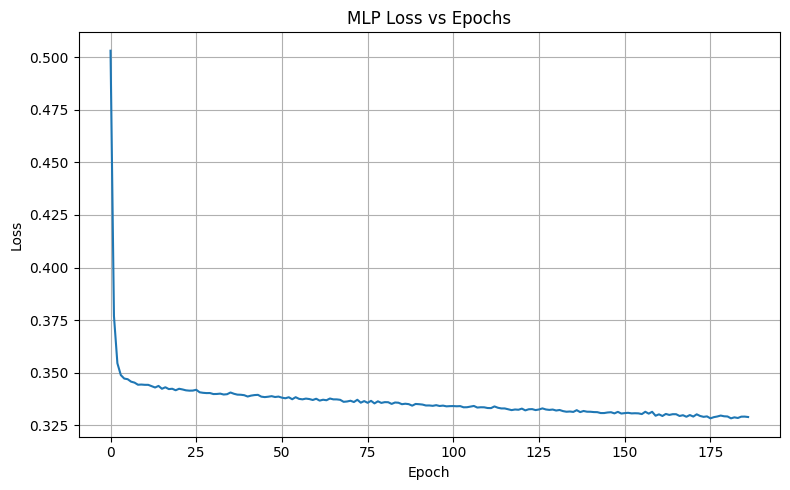

In [ ]:
# Plot the loss curve
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_)
plt.title("MLP Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

Tuning

In [ ]:
param_dist = {
    'hidden_layer_sizes': [(32,), (32,64), (64,), (100,)],
    'activation': ['logistic', 'relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'learning_rate_init': [0.0001, 0.001, 0.01, 0.1],
    'alpha': [0.0001, 0.001, 0.01]
}

rand_search = random_search = RandomizedSearchCV(
    MLPClassifier(max_iter=500, random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)
rand_search.fit(X_train, y_train)

print("Best Parameters:", rand_search.best_params_)

best_mlp = rand_search.best_estimator_
y_pred3 = best_mlp.predict(X_test)
y_proba3 = best_mlp.predict_proba(X_test)[:, 1]  # For ROC curve

print("Classification Report - Tuned Multi-Layer Perceptron:")
report3 = classification_report(y_test, y_pred3, output_dict=True)
print(classification_report(y_test, y_pred3))

cv_results = pd.DataFrame(rand_search.cv_results_)
display(cv_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values('rank_test_score'))

Best Parameters: {'solver': 'adam', 'learning_rate_init': 0.0001, 'hidden_layer_sizes': (100,), 'alpha': 0.001, 'activation': 'logistic'}
Classification Report - Tuned Multi-Layer Perceptron:
              precision    recall  f1-score   support

       False       0.82      0.78      0.80      2343
        True       0.85      0.88      0.86      3238

    accuracy                           0.84      5581
   macro avg       0.83      0.83      0.83      5581
weighted avg       0.84      0.84      0.84      5581



,params,mean_test_score,std_test_score,rank_test_score
14,"{'solver': 'adam', 'learning_rate_init': 0.000...",0.848880,0.002465,1
3,"{'solver': 'adam', 'learning_rate_init': 0.001...",0.848835,0.002595,2
4,"{'solver': 'sgd', 'learning_rate_init': 0.01, ...",0.848746,0.002201,3
1,"{'solver': 'sgd', 'learning_rate_init': 0.01, ...",0.848701,0.001750,4
15,"{'solver': 'adam', 'learning_rate_init': 0.000...",0.848656,0.002878,5
16,"{'solver': 'sgd', 'learning_rate_init': 0.01, ...",0.848522,0.003419,6
2,"{'solver': 'adam', 'learning_rate_init': 0.000...",0.848432,0.002638,7
8,"{'solver': 'sgd', 'learning_rate_init': 0.01, ...",0.848432,0.002867,7
17,"{'solver': 'adam', 'learning_rate_init': 0.000...",0.848432,0.002549,7
0,"{'solver': 'sgd', 'learning_rate_init': 0.01, ...",0.848297,0.002839,10


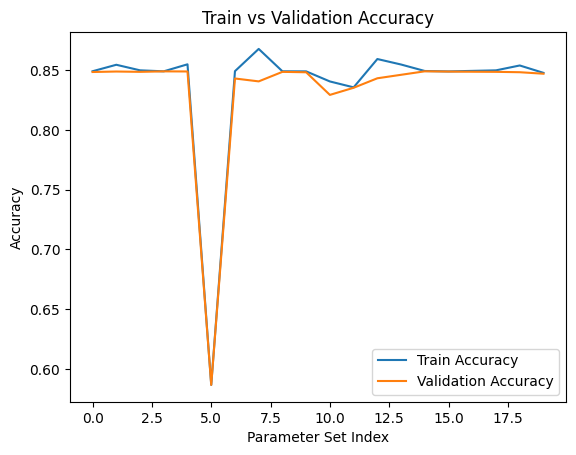

In [ ]:
plt.plot(cv_results["mean_train_score"], label="Train Accuracy")
plt.plot(cv_results["mean_test_score"], label="Validation Accuracy")
plt.legend()
plt.title("Train vs Validation Accuracy")
plt.xlabel("Parameter Set Index")
plt.ylabel("Accuracy")
plt.show()

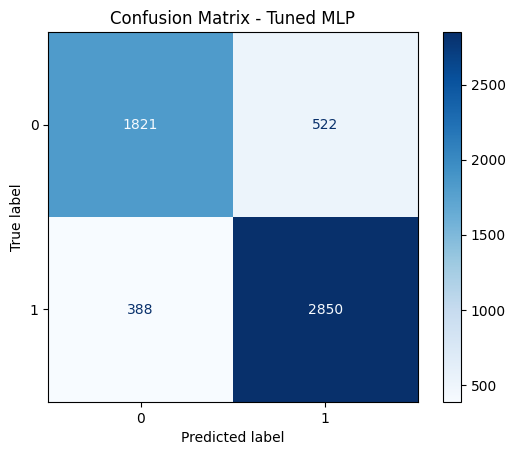

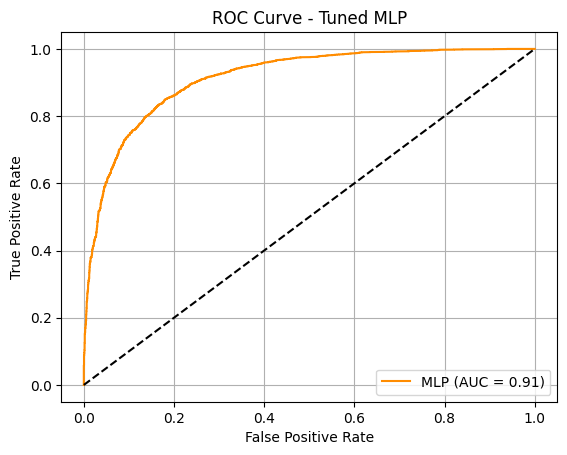

In [ ]:
cm = confusion_matrix(y_test, y_pred3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Tuned MLP")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba3)
roc_auc3 = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"MLP (AUC = {roc_auc3:.2f})", color='darkorange')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned MLP")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

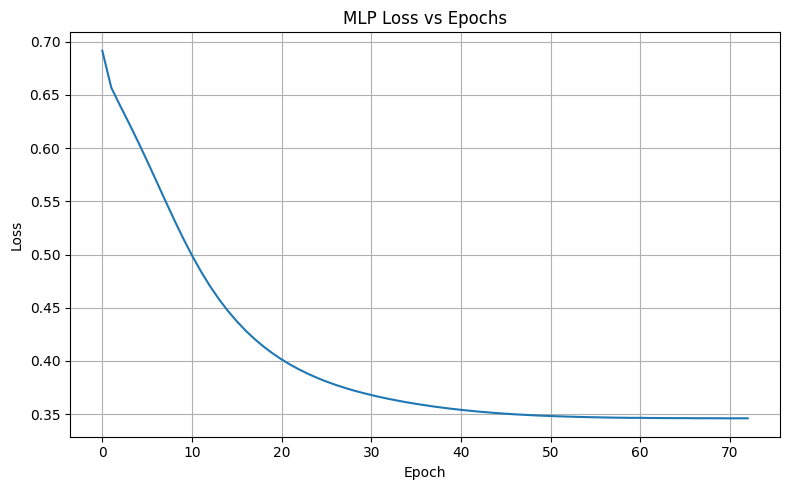

In [ ]:
# Plot the loss curve
plt.figure(figsize=(8, 5))
plt.plot(best_mlp.loss_curve_)
plt.title("MLP Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

**Comparison**

In [ ]:
labels1 = ["LR", "KNN", "MLP"]

accuracies1_before = [report1_before["accuracy"], report2_before["accuracy"], report3_before["accuracy"]]
accuracies1 = [report1["accuracy"], report2["accuracy"], report3["accuracy"]]

auc_before = [roc_auc1b, roc_auc2b, roc_auc3b]
auc = [roc_auc1, roc_auc2, roc_auc3]

#recall_scores1_before = [report1_before["weighted avg"]["recall"], report2_before["weighted avg"]["recall"], report3_before["weighted avg"]["recall"]]
#recall_scores1 = [report1["weighted avg"]["recall"], report2["weighted avg"]["recall"], report3["weighted avg"]["recall"]]

#precision_scores1_before = [report1_before["weighted avg"]["precision"], report2_before["weighted avg"]["precision"], report3_before["weighted avg"]["precision"]]
#precision_scores1 = [report1["weighted avg"]["precision"], report2["weighted avg"]["precision"], report3["weighted avg"]["precision"]]

#f1_scores1_before = [report1_before["weighted avg"]["f1-score"], report2_before["weighted avg"]["f1-score"], report3_before["weighted avg"]["f1-score"]]
#f1_scores1 = [report1["weighted avg"]["f1-score"], report2["weighted avg"]["f1-score"], report3["weighted avg"]["f1-score"]]

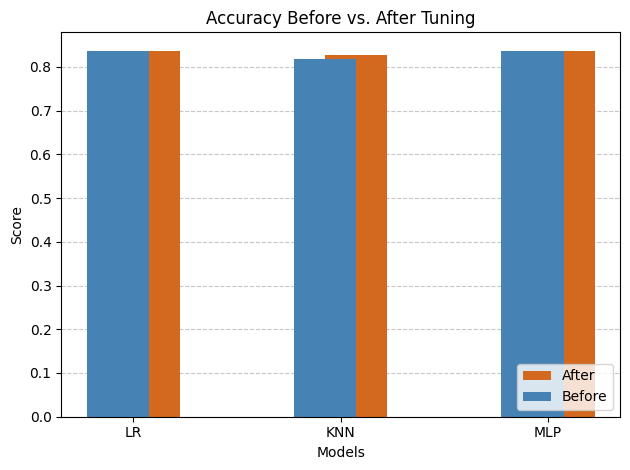

In [ ]:
x = np.arange(len(labels1))
width = 0.15

plt.bar(x + width/2, accuracies1, width*2, label='After', color='chocolate')
plt.bar(x - width/2, accuracies1_before, width*2, label='Before', color='steelblue')
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Accuracy Before vs. After Tuning')
plt.xticks(x, labels1)
plt.legend(loc="lower right")
plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

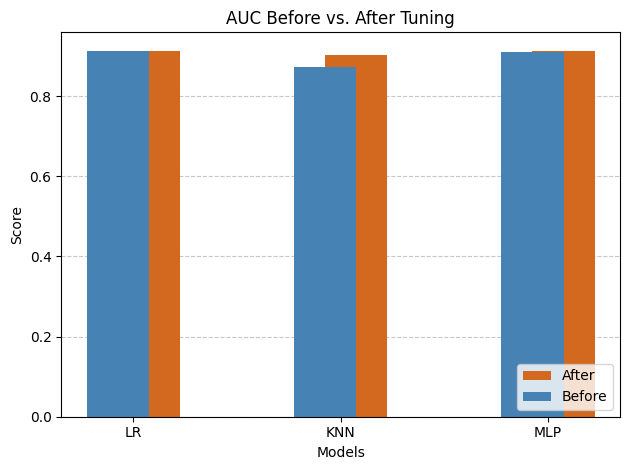

In [ ]:
x = np.arange(len(labels1))
width = 0.15

plt.bar(x + width/2, auc, width*2, label='After', color='chocolate')
plt.bar(x - width/2, auc_before, width*2, label='Before', color='steelblue')
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('AUC Before vs. After Tuning')
plt.xticks(x, labels1)
plt.legend(loc="lower right")
plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

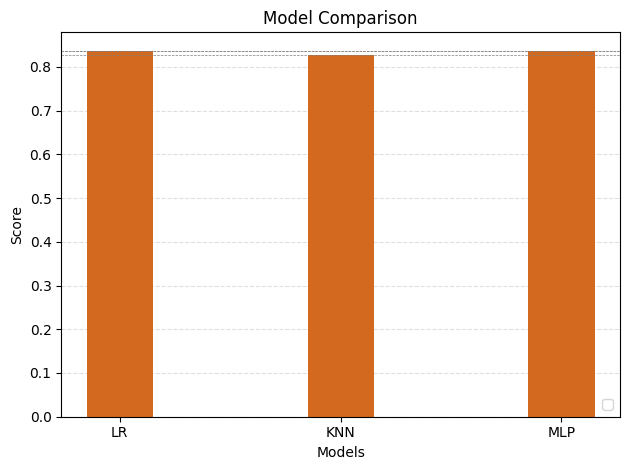

In [ ]:
x = np.arange(len(labels1))
width = 0.15

plt.bar(x, accuracies1, width*2, color='chocolate')
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Comparison')
plt.xticks(x, labels1)
plt.legend(loc="lower right")

# Add a line at the top of the bars for easier comparison
for height in accuracies1:
    plt.axhline(y=height, color='gray', linestyle='--', linewidth=0.5)

plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# **Dataset Two:** Student Performace📈

In [ ]:
performance_data = pd.read_csv("/content/StudentPerformanceData.csv")

print("Original data:")
print(performance_data.head())
print(performance_data.isnull().sum())

Original data:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test prepara

**Preprocessing**

In [ ]:
# Create average score colum for the regression task
performance_data["avg"] = performance_data[["math score", "reading score", "writing score"]].mean(axis=1)
performance_data['performance'] = performance_data['avg'].apply(lambda x: 1 if x >= 60 else 0)

performance_data.drop(["math score", "reading score", "writing score", "avg"], axis=1, inplace=True)

# One-hot encode
performance_data = pd.get_dummies(performance_data, drop_first=True)

print("Missing values after preprocessing:\n", performance_data.isna().sum())
performance_data.head()

Missing values after preprocessing:
 performance                                      0
gender_male                                      0
race/ethnicity_group B                           0
race/ethnicity_group C                           0
race/ethnicity_group D                           0
race/ethnicity_group E                           0
parental level of education_bachelor's degree    0
parental level of education_high school          0
parental level of education_master's degree      0
parental level of education_some college         0
parental level of education_some high school     0
lunch_standard                                   0
test preparation course_none                     0
dtype: int64


,performance,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,1,False,True,False,False,False,True,False,False,False,False,True,True
1,1,False,False,True,False,False,False,False,False,True,False,True,False
2,1,False,True,False,False,False,False,False,True,False,False,True,True
3,0,True,False,False,False,False,False,False,False,False,False,False,True
4,1,True,False,True,False,False,False,False,False,True,False,True,True


**Model Building**

In [ ]:
X = performance_data.drop("performance", axis=1)
y = performance_data["performance"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print(f"Train set class distribution:\n{y_train.value_counts()}")
print(f"Test set class distribution:\n{y_test.value_counts()}")

Train shape: (800, 12)
Test shape: (200, 12)
Train set class distribution:
performance
1    572
0    228
Name: count, dtype: int64
Test set class distribution:
performance
1    143
0     57
Name: count, dtype: int64


Logistic Regression

In [ ]:
lr_student = LogisticRegression(max_iter=1000)
lr_student.fit(X_train, y_train)

y_pred4_before = lr_student.predict(X_test)

print("Classification Report - Logistic Regression:")
report4_before = classification_report(y_test, y_pred4_before, output_dict=True)
print(classification_report(y_test, y_pred4_before))

Classification Report - Logistic Regression:
              precision    recall  f1-score   support

           0       0.39      0.21      0.27        57
           1       0.73      0.87      0.79       143

    accuracy                           0.68       200
   macro avg       0.56      0.54      0.53       200
weighted avg       0.63      0.68      0.65       200



<Figure size 600x400 with 0 Axes>

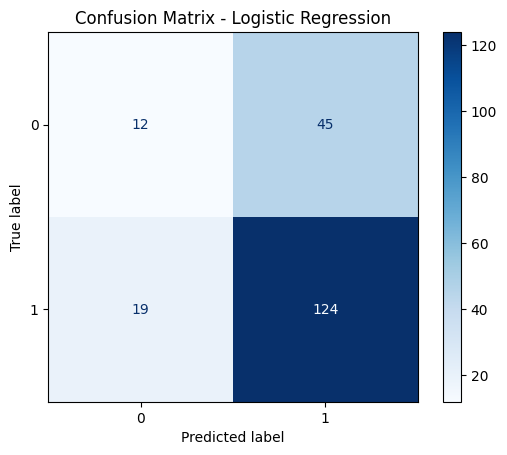

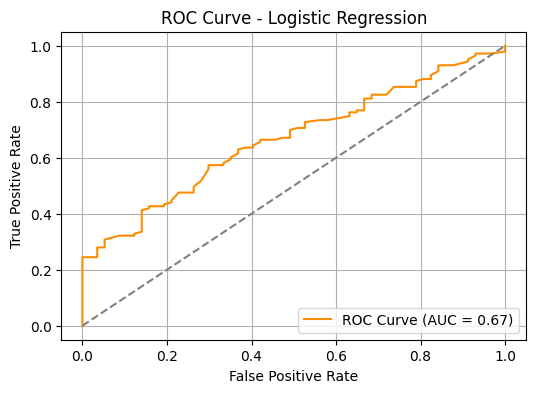

In [ ]:
# Confusion Matrix
plt.figure(figsize=(6, 4))
cm = ConfusionMatrixDisplay.from_estimator(lr_student, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.grid(False)
plt.show()

# ROC Curve
y_proba3_before = lr_student.predict_proba(X_test)[:, 1]
fpr_lr_student, tpr_lr_student, thresholds = roc_curve(y_test, y_proba3_before)
roc_auc4b = auc(fpr_lr_student, tpr_lr_student)

plt.figure(figsize=(6, 4))
plt.plot(fpr_lr_student, tpr_lr_student, label=f'ROC Curve (AUC = {roc_auc4b:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Tuning

In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

log_reg = LogisticRegression(max_iter=1000)

grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='accuracy', return_train_score=True)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

best_model = grid_search.best_estimator_
y_pred4 = best_model.predict(X_test)
y_proba4 = best_model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
report4 = classification_report(y_test, y_pred4, output_dict=True)
print(classification_report(y_test, y_pred4))

cv_results = pd.DataFrame(grid_search.cv_results_)
display(cv_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values('rank_test_score'))

Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.7537499999999999

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.14      0.21        57
           1       0.73      0.92      0.81       143

    accuracy                           0.69       200
   macro avg       0.56      0.53      0.51       200
weighted avg       0.63      0.69      0.64       200



,params,mean_test_score,std_test_score,rank_test_score
2,"{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.75375,0.018792,1
5,"{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}",0.75250,0.024238,2
3,"{'C': 0.1, 'penalty': 'l2', 'solver': 'libline...",0.75125,0.019922,3
4,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.75000,0.020917,4
0,"{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}",0.71500,0.003062,5
1,"{'C': 0.01, 'penalty': 'l2', 'solver': 'liblin...",0.71500,0.003062,5


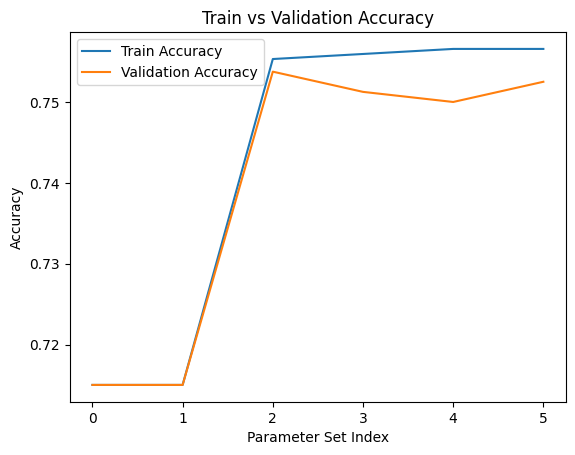

In [ ]:
plt.plot(cv_results["mean_train_score"], label="Train Accuracy")
plt.plot(cv_results["mean_test_score"], label="Validation Accuracy")
plt.legend()
plt.title("Train vs Validation Accuracy")
plt.xlabel("Parameter Set Index")
plt.ylabel("Accuracy")
plt.show()

<Figure size 600x400 with 0 Axes>

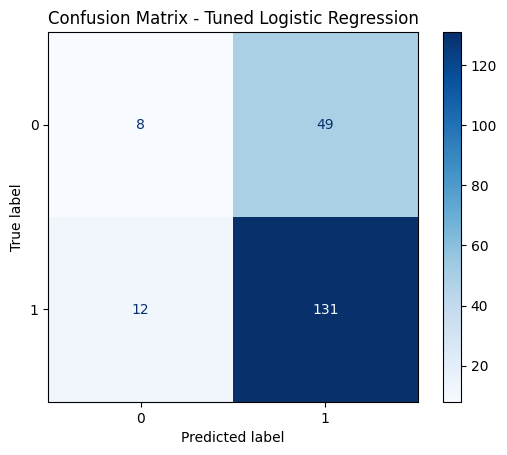

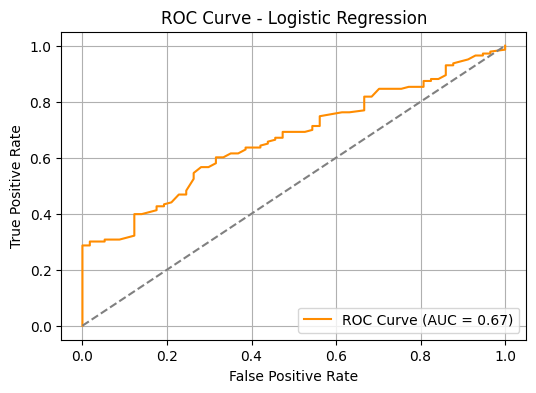

In [ ]:
# Confusion Matrix
plt.figure(figsize=(6, 4))
cm = ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.grid(False)
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba4)
roc_auc4 = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc4:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

K-Nearest Neighbor

In [ ]:
knn_student = KNeighborsClassifier(n_neighbors=5)
knn_student.fit(X_train, y_train)

y_pred5_before = knn_student.predict(X_test)

print("Classification Report - K-Nearest Neighbors:")
report5_before = classification_report(y_test, y_pred5_before, output_dict=True)
print(classification_report(y_test, y_pred5_before))

Classification Report - K-Nearest Neighbors:
              precision    recall  f1-score   support

           0       0.41      0.30      0.35        57
           1       0.75      0.83      0.79       143

    accuracy                           0.68       200
   macro avg       0.58      0.57      0.57       200
weighted avg       0.65      0.68      0.66       200



<Figure size 600x400 with 0 Axes>

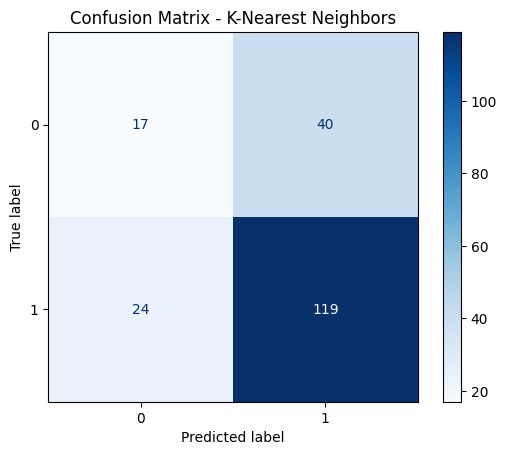

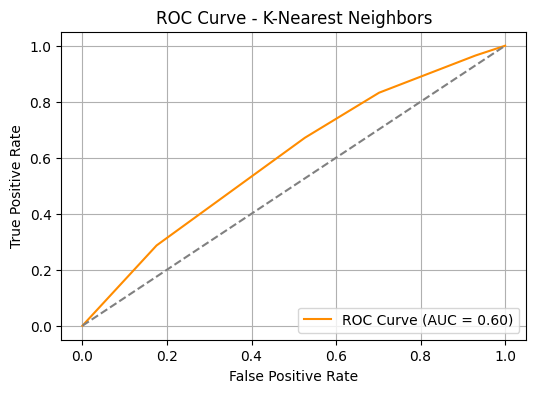

In [ ]:
# Confusion Matrix
plt.figure(figsize=(6, 4))
cm = ConfusionMatrixDisplay.from_estimator(knn_student, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix - K-Nearest Neighbors")
plt.grid(False)
plt.show()

# ROC Curve
y_proba5_before = knn_student.predict_proba(X_test)[:, 1]
fpr_knn_student, tpr_knn_student, thresholds = roc_curve(y_test, y_proba5_before)
roc_auc5b = auc(fpr_knn_student, tpr_knn_student)

plt.figure(figsize=(6, 4))
plt.plot(fpr_knn_student, tpr_knn_student, label=f'ROC Curve (AUC = {roc_auc5b:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - K-Nearest Neighbors")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Tuning

In [ ]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn = KNeighborsClassifier()
grid_search_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy', return_train_score=True)
grid_search_knn.fit(X_train, y_train)

print("Best Parameters for KNN:", grid_search_knn.best_params_)
print("Best Cross-Validation Accuracy for KNN:", grid_search_knn.best_score_)

best_knn_model = grid_search_knn.best_estimator_
y_pred5 = best_knn_model.predict(X_test)
y_proba5 = best_knn_model.predict_proba(X_test)[:, 1]

print("\nClassification Report for KNN:")
report5 = classification_report(y_test, y_pred5, output_dict=True)
print(classification_report(y_test, y_pred5))

cv_results_knn = pd.DataFrame(grid_search_knn.cv_results_)
display(cv_results_knn[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values('rank_test_score'))

Best Parameters for KNN: {'metric': 'euclidean', 'n_neighbors': 21, 'weights': 'uniform'}
Best Cross-Validation Accuracy for KNN: 0.735

Classification Report for KNN:
              precision    recall  f1-score   support

           0       0.50      0.12      0.20        57
           1       0.73      0.95      0.83       143

    accuracy                           0.71       200
   macro avg       0.62      0.54      0.51       200
weighted avg       0.67      0.71      0.65       200



,params,mean_test_score,std_test_score,rank_test_score
10,"{'metric': 'euclidean', 'n_neighbors': 21, 'we...",0.73500,0.028395,1
22,"{'metric': 'manhattan', 'n_neighbors': 21, 'we...",0.73500,0.028395,1
20,"{'metric': 'manhattan', 'n_neighbors': 11, 'we...",0.72250,0.026398,3
8,"{'metric': 'euclidean', 'n_neighbors': 11, 'we...",0.72250,0.026398,3
0,"{'metric': 'euclidean', 'n_neighbors': 3, 'wei...",0.71500,0.034141,5
12,"{'metric': 'manhattan', 'n_neighbors': 3, 'wei...",0.71500,0.034141,5
4,"{'metric': 'euclidean', 'n_neighbors': 7, 'wei...",0.70875,0.033213,7
16,"{'metric': 'manhattan', 'n_neighbors': 7, 'wei...",0.70875,0.033213,7
18,"{'metric': 'manhattan', 'n_neighbors': 9, 'wei...",0.70750,0.027500,9
6,"{'metric': 'euclidean', 'n_neighbors': 9, 'wei...",0.70750,0.027500,9


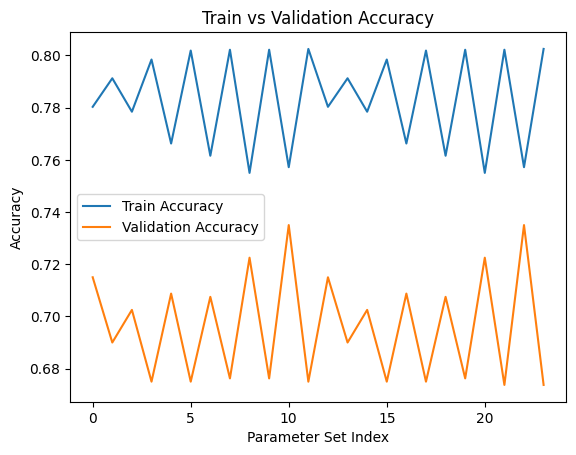

In [ ]:
plt.plot(cv_results_knn["mean_train_score"], label="Train Accuracy")
plt.plot(cv_results_knn["mean_test_score"], label="Validation Accuracy")
plt.legend()
plt.title("Train vs Validation Accuracy")
plt.xlabel("Parameter Set Index")
plt.ylabel("Accuracy")
plt.show()

<Figure size 600x400 with 0 Axes>

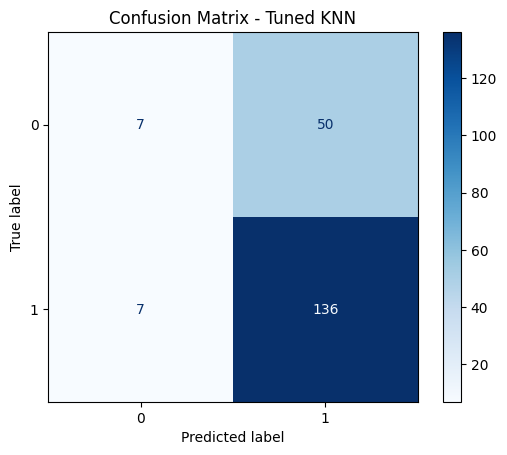

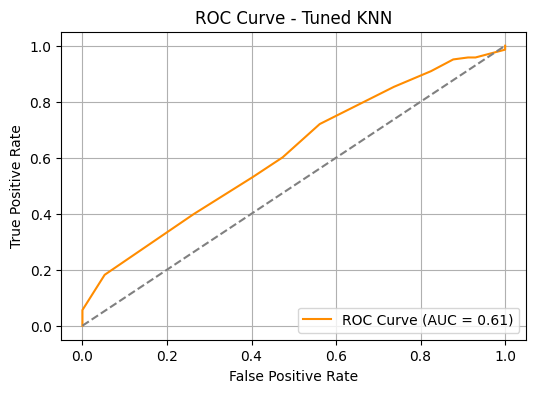

In [ ]:
# Confusion Matrix
plt.figure(figsize=(6, 4))
cm = ConfusionMatrixDisplay.from_estimator(best_knn_model, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix - Tuned KNN")
plt.grid(False)
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba5)
roc_auc5 = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc5:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned KNN")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Multi-Layer Perceptron

In [ ]:
mlp_student = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
mlp_student.fit(X_train, y_train)

y_pred6_before = mlp_student.predict(X_test)

print("Classification Report - Multi-Layer Perceptron:")
report6_before = classification_report(y_test, y_pred6_before, output_dict=True)
print(classification_report(y_test, y_pred6_before))

Classification Report - Multi-Layer Perceptron:
              precision    recall  f1-score   support

           0       0.48      0.25      0.33        57
           1       0.75      0.90      0.82       143

    accuracy                           0.71       200
   macro avg       0.62      0.57      0.57       200
weighted avg       0.67      0.71      0.68       200



<Figure size 600x400 with 0 Axes>

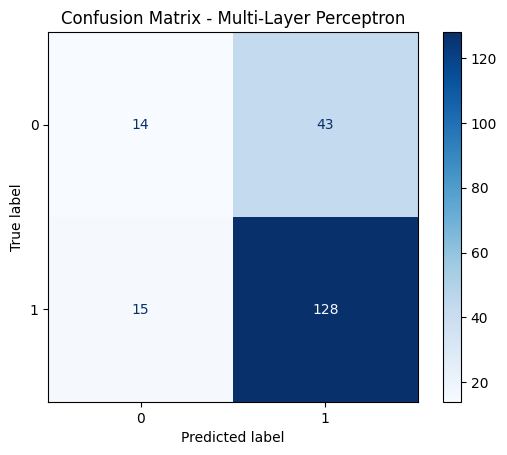

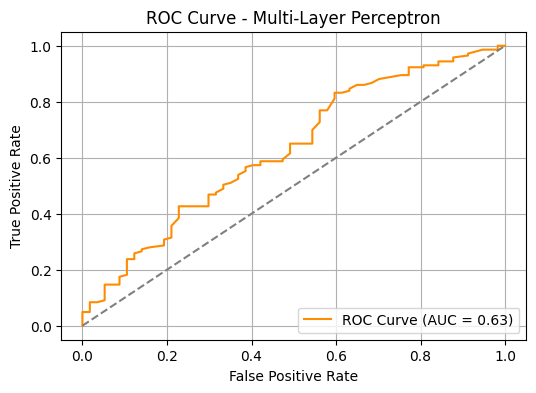

In [ ]:
# Confusion Matrix
plt.figure(figsize=(6, 4))
cm = ConfusionMatrixDisplay.from_estimator(mlp_student, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix - Multi-Layer Perceptron")
plt.grid(False)
plt.show()

# ROC Curve
y_proba6_before = mlp_student.predict_proba(X_test)[:, 1]
fpr_mlp_student, tpr_mlp_student, thresholds = roc_curve(y_test, y_proba6_before)
roc_auc6b = auc(fpr_mlp_student, tpr_mlp_student)

plt.figure(figsize=(6, 4))
plt.plot(fpr_mlp_student, tpr_mlp_student, label=f'ROC Curve (AUC = {roc_auc6b:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multi-Layer Perceptron")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

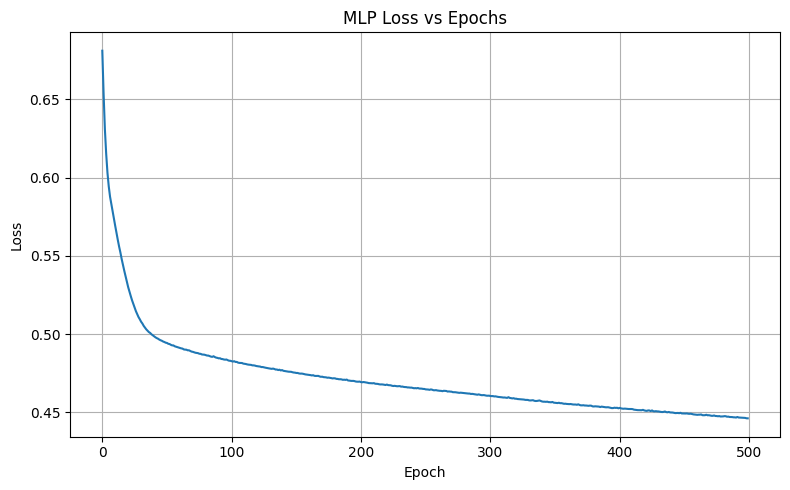

In [ ]:
# Plot the loss curve
plt.figure(figsize=(8, 5))
plt.plot(mlp_student.loss_curve_)
plt.title("MLP Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

Tuning

In [ ]:
param_dist = {
    'hidden_layer_sizes': [(32,32), (32,), (64,), (64, 32), (100,)],
    'activation': ['logistic', 'relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'learning_rate_init': [0.0001, 0.001, 0.01, 0.1],
    'alpha': [0.0001, 0.001, 0.01],
    #'batch_size': [1, 16, 32, 64, 128]
}

rand_search = random_search = RandomizedSearchCV(
    MLPClassifier(max_iter=500, random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)
rand_search.fit(X_train, y_train)

print("Best Parameters:", rand_search.best_params_)

best_mlp = rand_search.best_estimator_
y_pred6 = best_mlp.predict(X_test)
y_proba6 = best_mlp.predict_proba(X_test)[:, 1]  # For ROC curve

print("Classification Report - Tuned Multi-Layer Perceptron:")
report6 = classification_report(y_test, y_pred6, output_dict=True)
print(classification_report(y_test, y_pred6))

cv_results = pd.DataFrame(rand_search.cv_results_)
display(cv_results[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values('rank_test_score'))

Best Parameters: {'solver': 'adam', 'learning_rate_init': 0.0001, 'hidden_layer_sizes': (32,), 'alpha': 0.0001, 'activation': 'tanh'}
Classification Report - Tuned Multi-Layer Perceptron:
              precision    recall  f1-score   support

           0       0.41      0.16      0.23        57
           1       0.73      0.91      0.81       143

    accuracy                           0.69       200
   macro avg       0.57      0.53      0.52       200
weighted avg       0.64      0.69      0.64       200



,params,mean_test_score,std_test_score,rank_test_score
8,"{'solver': 'adam', 'learning_rate_init': 0.000...",0.75500,0.016008,1
2,"{'solver': 'sgd', 'learning_rate_init': 0.01, ...",0.74625,0.025800,2
11,"{'solver': 'adam', 'learning_rate_init': 0.001...",0.74625,0.021139,2
16,"{'solver': 'sgd', 'learning_rate_init': 0.001,...",0.74625,0.023585,2
18,"{'solver': 'sgd', 'learning_rate_init': 0.001,...",0.74625,0.025495,2
6,"{'solver': 'sgd', 'learning_rate_init': 0.1, '...",0.74625,0.025800,6
10,"{'solver': 'adam', 'learning_rate_init': 0.001...",0.74375,0.019764,7
17,"{'solver': 'adam', 'learning_rate_init': 0.01,...",0.74250,0.024812,8
5,"{'solver': 'adam', 'learning_rate_init': 0.000...",0.74250,0.023519,9
12,"{'solver': 'adam', 'learning_rate_init': 0.001...",0.74250,0.023519,9


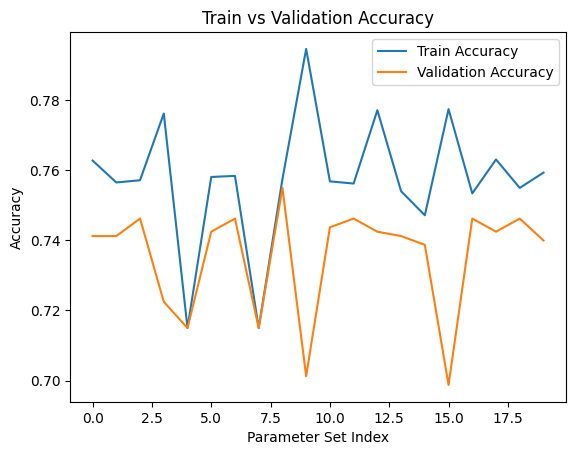

In [ ]:
plt.plot(cv_results["mean_train_score"], label="Train Accuracy")
plt.plot(cv_results["mean_test_score"], label="Validation Accuracy")
plt.legend()
plt.title("Train vs Validation Accuracy")
plt.xlabel("Parameter Set Index")
plt.ylabel("Accuracy")
plt.show()

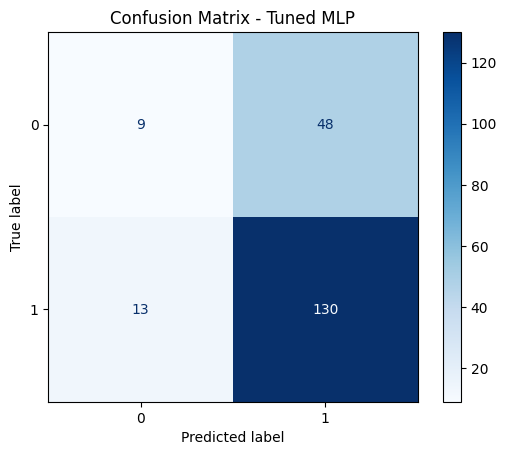

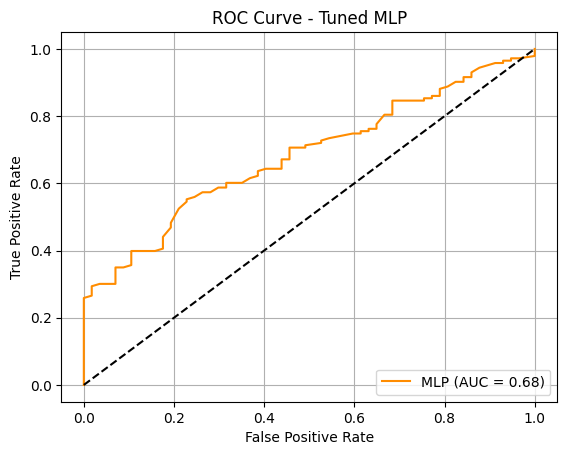

In [ ]:
cm = confusion_matrix(y_test, y_pred6)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Tuned MLP")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba6)
roc_auc6 = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"MLP (AUC = {roc_auc6:.2f})", color='darkorange')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned MLP")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

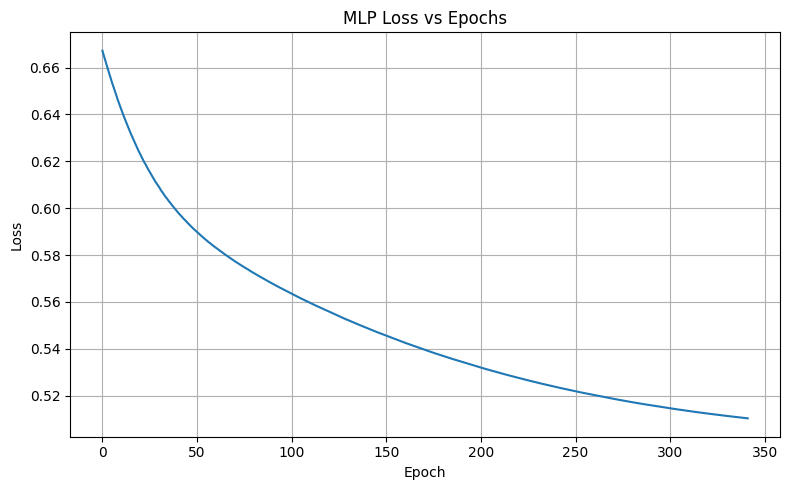

In [ ]:
# Plot the loss curve
plt.figure(figsize=(8, 5))
plt.plot(best_mlp.loss_curve_)
plt.title("MLP Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

**Comparison**

In [ ]:
labels2 = ["LR", "KNN", "MLP"]

accuracies2_before = [report4_before["accuracy"], report5_before["accuracy"], report6_before["accuracy"]]
accuracies2 = [report4["accuracy"], report5["accuracy"], report6["accuracy"]]

auc_before2 = [roc_auc4b, roc_auc5b, roc_auc6b]
auc2 = [roc_auc4, roc_auc5, roc_auc6]

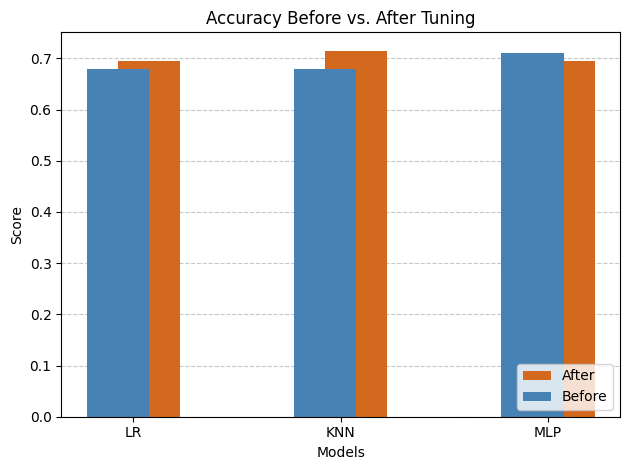

In [ ]:
x = np.arange(len(labels2))
width = 0.15

plt.bar(x + width/2, accuracies2, width*2, label='After', color='chocolate')
plt.bar(x - width/2, accuracies2_before, width*2, label='Before', color='steelblue')
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Accuracy Before vs. After Tuning')
plt.xticks(x, labels2)
plt.legend(loc="lower right")
plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

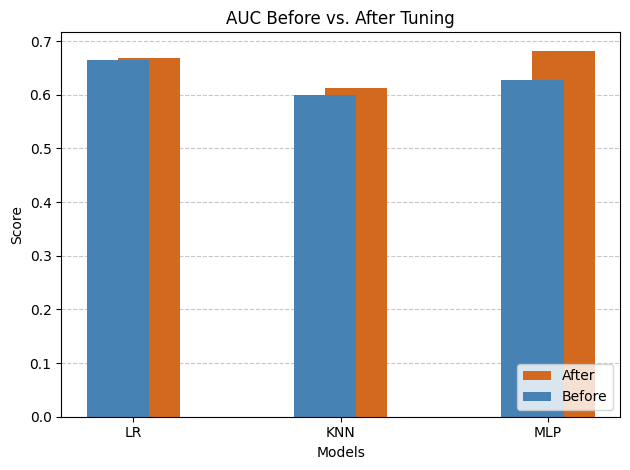

In [ ]:
x = np.arange(len(labels2))
width = 0.15

plt.bar(x + width/2, auc2, width*2, label='After', color='chocolate')
plt.bar(x - width/2, auc_before2, width*2, label='Before', color='steelblue')
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('AUC Before vs. After Tuning')
plt.xticks(x, labels2)
plt.legend(loc="lower right")
plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

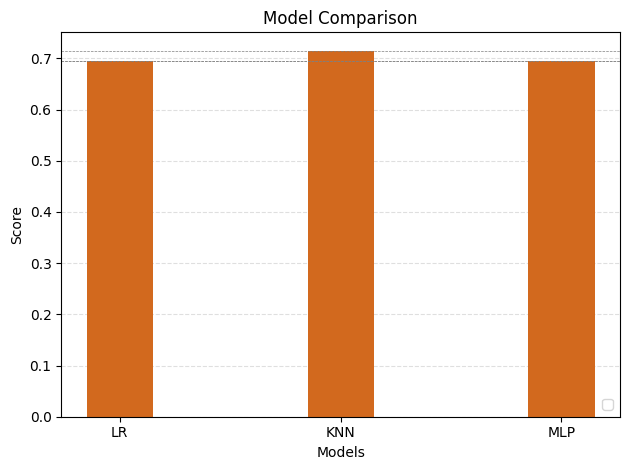

In [ ]:
x = np.arange(len(labels2))
width = 0.15

plt.bar(x, accuracies2, width*2, color='chocolate')
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Comparison')
plt.xticks(x, labels2)
plt.legend(loc="lower right")

# Add a line at the top of the bars for easier comparison
for height in accuracies2:
    plt.axhline(y=height, color='gray', linestyle='--', linewidth=0.5)

plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# **Dataset Three:** Life Expectancy💜

In [ ]:
life_data = pd.read_csv("/content/LifeExpectancyData.csv")

print("Original data:")
print(life_data.head())
print(life_data.isnull().sum())

Original data:
       Country  Year      Status  Life expectancy   Adult Mortality  \
0  Afghanistan  2015  Developing              65.0            263.0   
1  Afghanistan  2014  Developing              59.9            271.0   
2  Afghanistan  2013  Developing              59.9            268.0   
3  Afghanistan  2012  Developing              59.5            272.0   
4  Afghanistan  2011  Developing              59.2            275.0   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles   ...  \
0             62     0.01               71.279624         65.0      1154  ...   
1             64     0.01               73.523582         62.0       492  ...   
2             66     0.01               73.219243         64.0       430  ...   
3             69     0.01               78.184215         67.0      2787  ...   
4             71     0.01                7.097109         68.0      3013  ...   

   Polio  Total expenditure  Diphtheria    HIV/AIDS         GDP  Popula

**Preprocessing**

In [ ]:
unwanted_cols = ['Country', 'Year']

life_data.drop(unwanted_cols, axis=1, inplace=True)

# Encode categorical variables
label_encoder = LabelEncoder()
life_data['Status'] = label_encoder.fit_transform(life_data['Status'])

# Fill missing values
imputer = SimpleImputer(strategy='mean')
life_data = pd.DataFrame(imputer.fit_transform(life_data), columns=life_data.columns)
print("Cleaned data:")
print(life_data.head())
print()
print(life_data.isnull().sum())

Cleaned data:
   Status  Life expectancy   Adult Mortality  infant deaths  Alcohol  \
0     1.0              65.0            263.0           62.0     0.01   
1     1.0              59.9            271.0           64.0     0.01   
2     1.0              59.9            268.0           66.0     0.01   
3     1.0              59.5            272.0           69.0     0.01   
4     1.0              59.2            275.0           71.0     0.01   

   percentage expenditure  Hepatitis B  Measles    BMI   under-five deaths   \
0               71.279624         65.0    1154.0   19.1                83.0   
1               73.523582         62.0     492.0   18.6                86.0   
2               73.219243         64.0     430.0   18.1                89.0   
3               78.184215         67.0    2787.0   17.6                93.0   
4                7.097109         68.0    3013.0   17.2                97.0   

   Polio  Total expenditure  Diphtheria    HIV/AIDS         GDP  Population  \

**Model Building**

In [ ]:
X = life_data.drop(['Life expectancy '], axis=1)
y = life_data['Life expectancy ']

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Linear Regression

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred7_before = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred7_before)
mse = mean_squared_error(y_test, y_pred7_before)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred7_before)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 2.8579
MSE: 15.2380
RMSE: 3.9036
R²: 0.8241


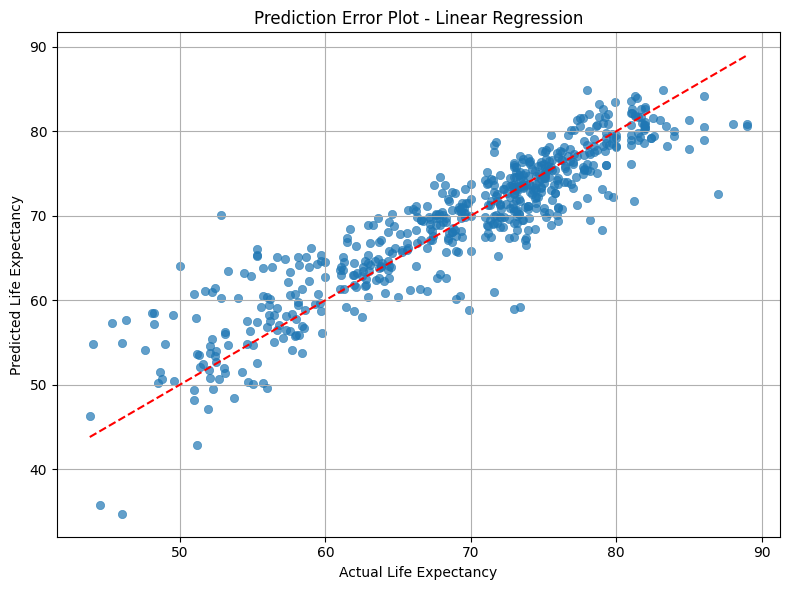

In [ ]:
# Prediction Error Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred7_before, alpha=0.7, edgecolor=None)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title('Prediction Error Plot - Linear Regression')
plt.grid(True)
plt.tight_layout()
plt.show()

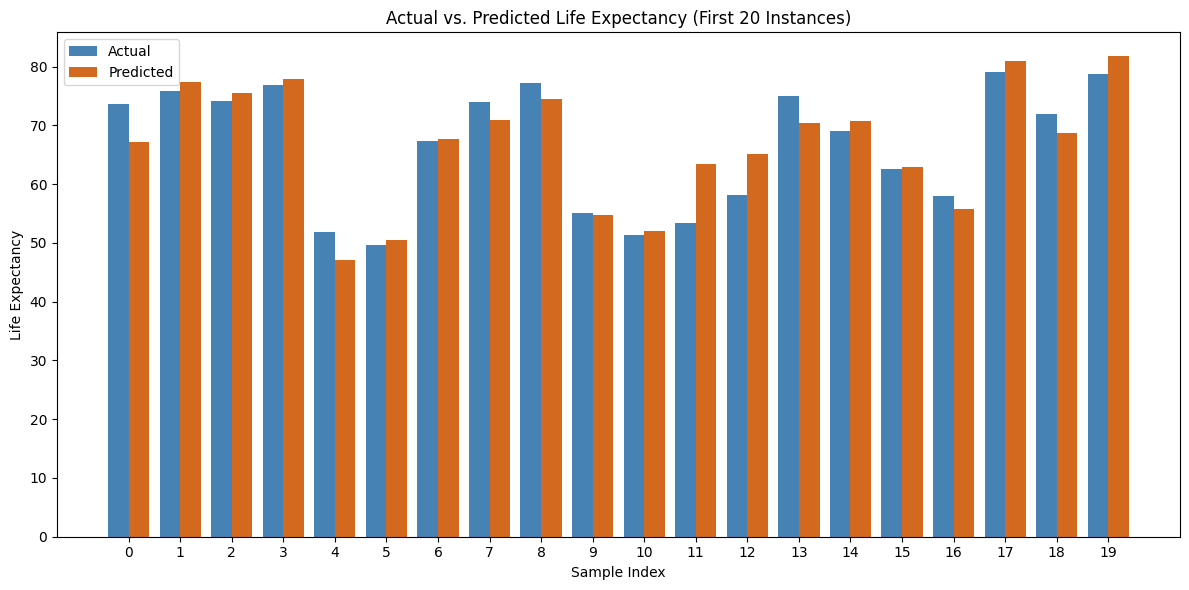

In [ ]:
# Plot predicted vs actual
n = 20
x_axis = np.arange(n)

bar_width = 0.4

plt.figure(figsize=(12, 6))
plt.bar(x_axis - bar_width/2, y_test[:n].values, width=bar_width, label='Actual', color='steelblue')
plt.bar(x_axis + bar_width/2, y_pred7_before[:n], width=bar_width, label='Predicted', color='chocolate')

plt.title("Actual vs. Predicted Life Expectancy (First 20 Instances)")
plt.xlabel("Sample Index")
plt.ylabel("Life Expectancy")
plt.xticks(x_axis)
plt.legend()
#plt.grid(axis='y')
plt.tight_layout()
plt.show()

Tuning

In [ ]:
lin_reg = LinearRegression()

param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}
grid_search = GridSearchCV(lin_reg, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(X_train, y_train)
#print(f"Cross-validation MSE: {-cv_scores.mean():.4f}")
print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_

y_pred7 = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred7)
mae = mean_absolute_error(y_test, y_pred7)
rmse = mse**0.5
r2 = r2_score(y_test, y_pred7)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

Best Parameters: {'fit_intercept': True, 'positive': False}
MAE: 2.8579
MSE: 15.2380
RMSE: 3.9036
R²: 0.8241


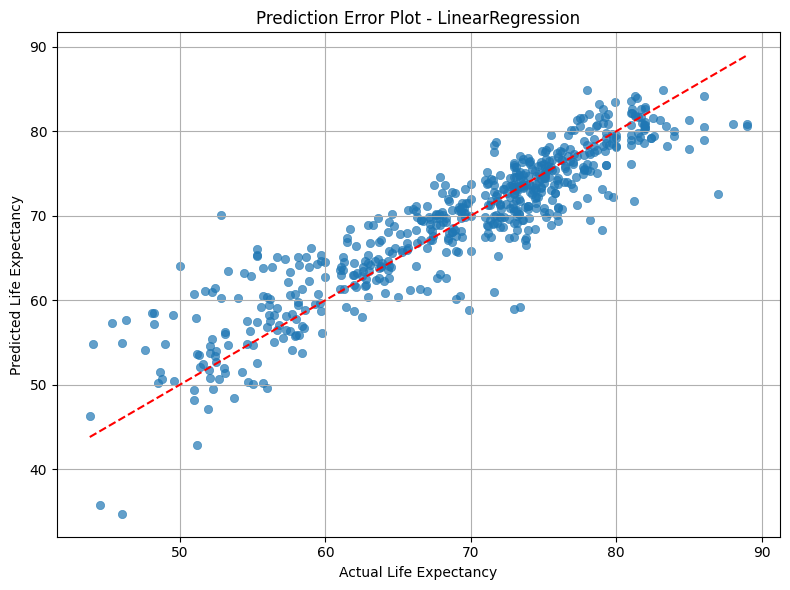

In [ ]:
# Prediction Error Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred7, alpha=0.7, edgecolor=None)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title('Prediction Error Plot - LinearRegression')
plt.grid(True)
plt.tight_layout()
plt.show()

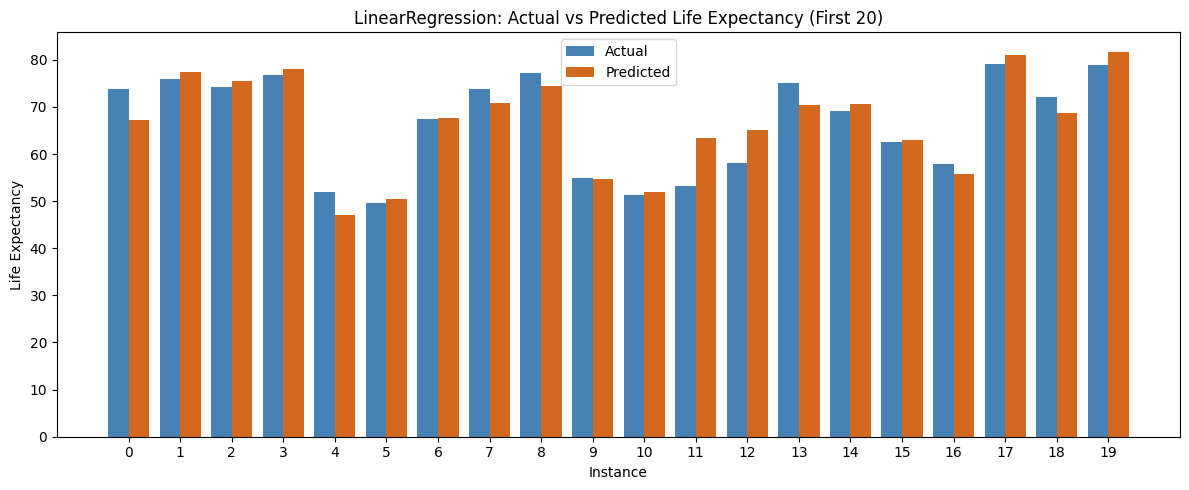

In [ ]:
# Plot predicted vs actual
plt.figure(figsize=(12, 5))
x_range = np.arange(20)
plt.bar(x_range - 0.2, y_test.values[:20], width=0.4, label='Actual', color='steelblue')
plt.bar(x_range + 0.2, y_pred7[:20], width=0.4, label='Predicted', color='chocolate')
plt.title('LinearRegression: Actual vs Predicted Life Expectancy (First 20)')
plt.xlabel('Instance')
plt.ylabel('Life Expectancy')
plt.xticks(x_axis)
plt.legend()
plt.tight_layout()
plt.show()

ElasticNet

In [ ]:
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
elastic.fit(X_train, y_train)

y_pred8_before = elastic.predict(X_test)

mae = mean_absolute_error(y_test, y_pred8_before)
mse = mean_squared_error(y_test, y_pred8_before)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred8_before)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 2.9507
MSE: 16.2808
RMSE: 4.0350
R²: 0.8121


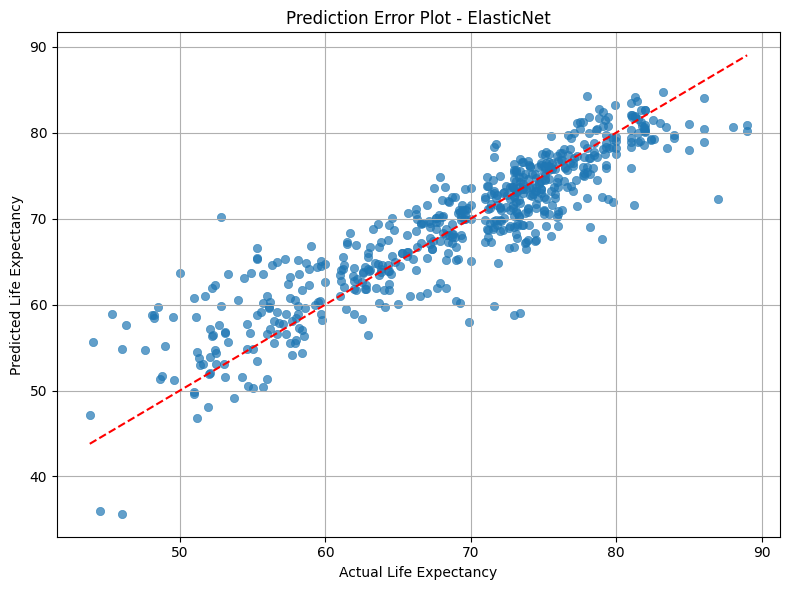

In [ ]:
# Prediction Error Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred8_before, alpha=0.7, edgecolor=None)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title('Prediction Error Plot - ElasticNet')
plt.grid(True)
plt.tight_layout()
plt.show()

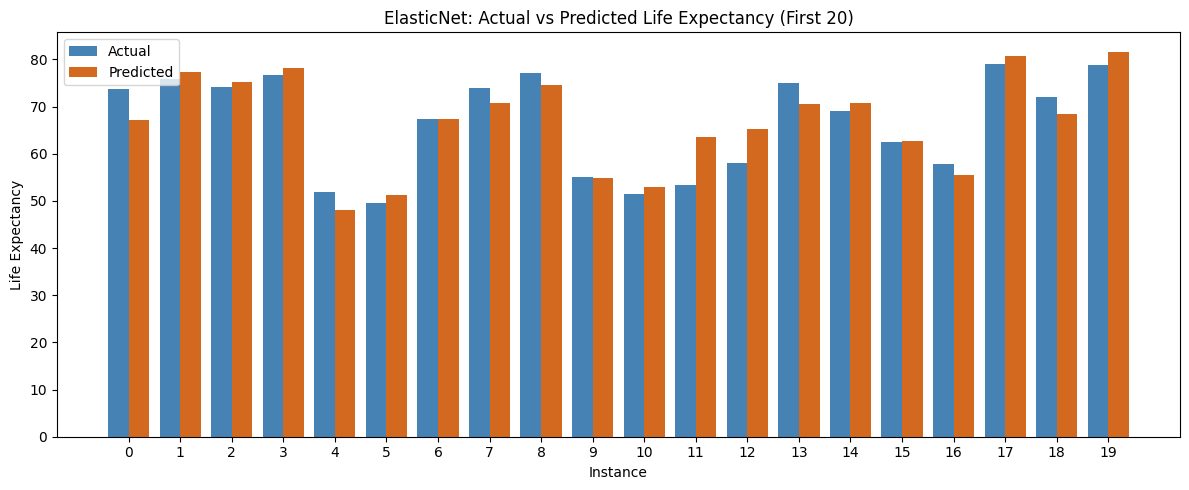

In [ ]:
# Plot predicted vs actual
plt.figure(figsize=(12, 5))
x_range = np.arange(20)
plt.bar(x_range - 0.2, y_test.values[:20], width=0.4, label='Actual', color='steelblue')
plt.bar(x_range + 0.2, y_pred8_before[:20], width=0.4, label='Predicted', color='chocolate')
plt.title('ElasticNet: Actual vs Predicted Life Expectancy (First 20)')
plt.xlabel('Instance')
plt.ylabel('Life Expectancy')
plt.xticks(x_axis)
plt.legend()
plt.tight_layout()
plt.show()

Tuning

In [ ]:
elastic = ElasticNet()

param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
    'max_iter': [1000, 2000]
}
grid_search = GridSearchCV(elastic, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred8 = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred8)
mse = mean_squared_error(y_test, y_pred8)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred8)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'alpha': 0.01, 'l1_ratio': 0.9, 'max_iter': 1000}
MAE: 2.8786
MSE: 15.5138
RMSE: 3.9388
R²: 0.8209


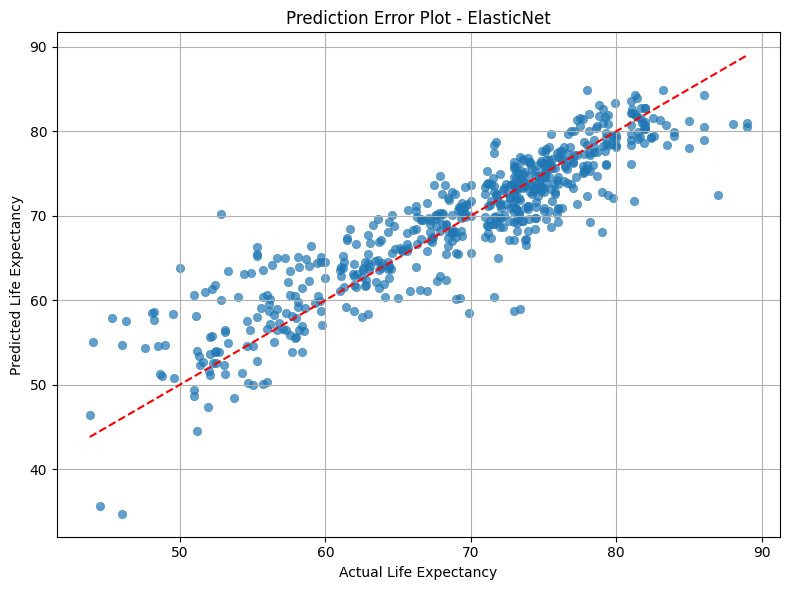

In [ ]:
# Prediction Error Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred8, alpha=0.7, edgecolor=None)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title('Prediction Error Plot - ElasticNet')
plt.grid(True)
plt.tight_layout()
plt.show()

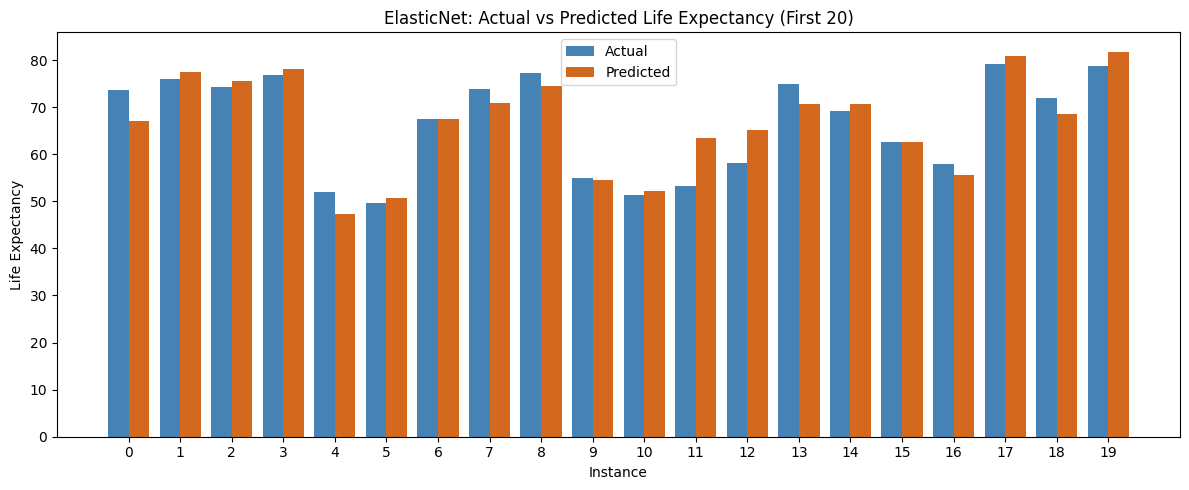

In [ ]:
# Plot predicted vs actual
plt.figure(figsize=(12, 5))
x_range = np.arange(20)
plt.bar(x_range - 0.2, y_test.values[:20], width=0.4, label='Actual', color='steelblue')
plt.bar(x_range + 0.2, y_pred8[:20], width=0.4, label='Predicted', color='chocolate')
plt.title('ElasticNet: Actual vs Predicted Life Expectancy (First 20)')
plt.xlabel('Instance')
plt.ylabel('Life Expectancy')
plt.xticks(x_axis)
plt.legend()
plt.tight_layout()
plt.show()

K-Nearest Neighbor

In [ ]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred9_before = knn.predict(X_test)

mae = mean_absolute_error(y_test, y_pred9_before)
mse = mean_squared_error(y_test, y_pred9_before)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred9_before)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 1.8215
MSE: 6.6917
RMSE: 2.5868
R²: 0.9228


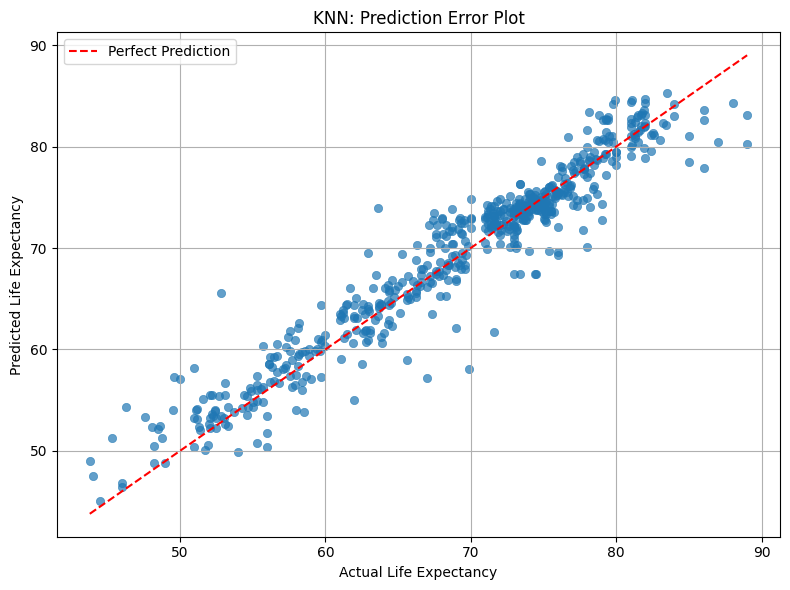

In [ ]:
# Prediction Error Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred9_before, alpha=0.7, edgecolor=None)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', label='Perfect Prediction')
plt.title("KNN: Prediction Error Plot")
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

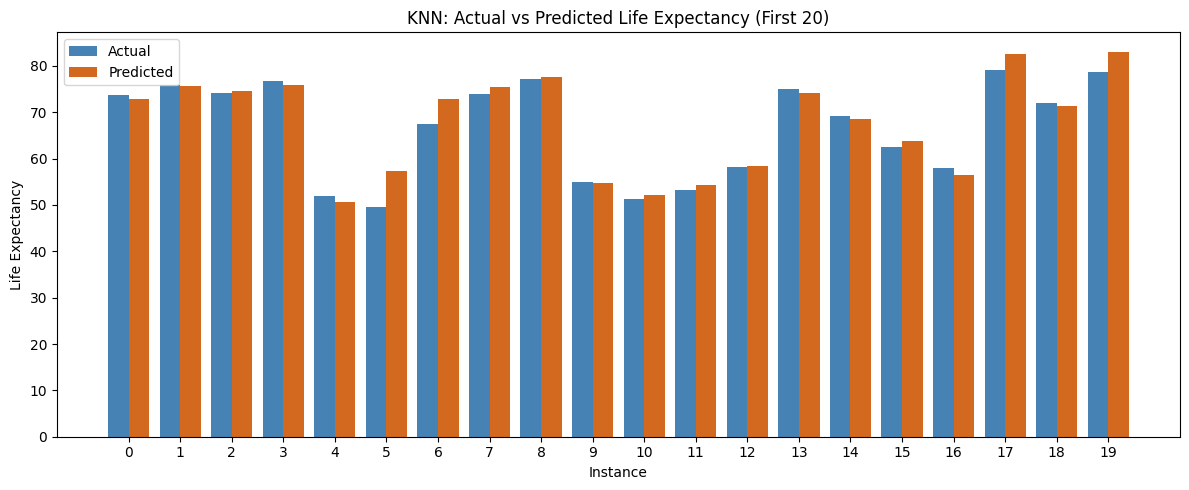

In [ ]:
# Plot predicted vs actual
plt.figure(figsize=(12, 5))
x_range = np.arange(20)
plt.bar(x_range - 0.2, y_test.values[:20], width=0.4, label='Actual', color='steelblue')
plt.bar(x_range + 0.2, y_pred9_before[:20], width=0.4, label='Predicted', color='chocolate')
plt.title('KNN: Actual vs Predicted Life Expectancy (First 20)')
plt.xlabel('Instance')
plt.ylabel('Life Expectancy')
plt.xticks(x_axis)
plt.legend()
plt.tight_layout()
plt.show()

Tuning

In [ ]:
knn_model = KNeighborsRegressor()

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 27],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # p=1 for Manhattan, p=2 for Euclidean distance
}

grid_search = GridSearchCV(knn_model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

best_knn_model = grid_search.best_estimator_
y_pred9 = best_knn_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred9)
mse = mean_squared_error(y_test, y_pred9)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred9)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Best Parameters: {'n_neighbors': 5, 'p': 1, 'weights': 'distance'}
MAE: 1.3535
MSE: 4.4183
RMSE: 2.1020
R²: 0.9490


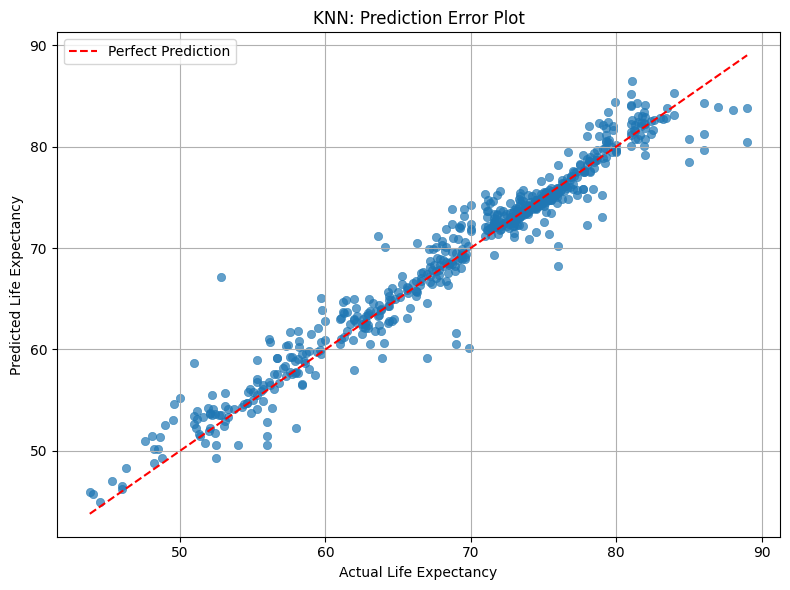

In [ ]:
# Prediction Error Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred9, alpha=0.7, edgecolor=None)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', label='Perfect Prediction')
plt.title("KNN: Prediction Error Plot")
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

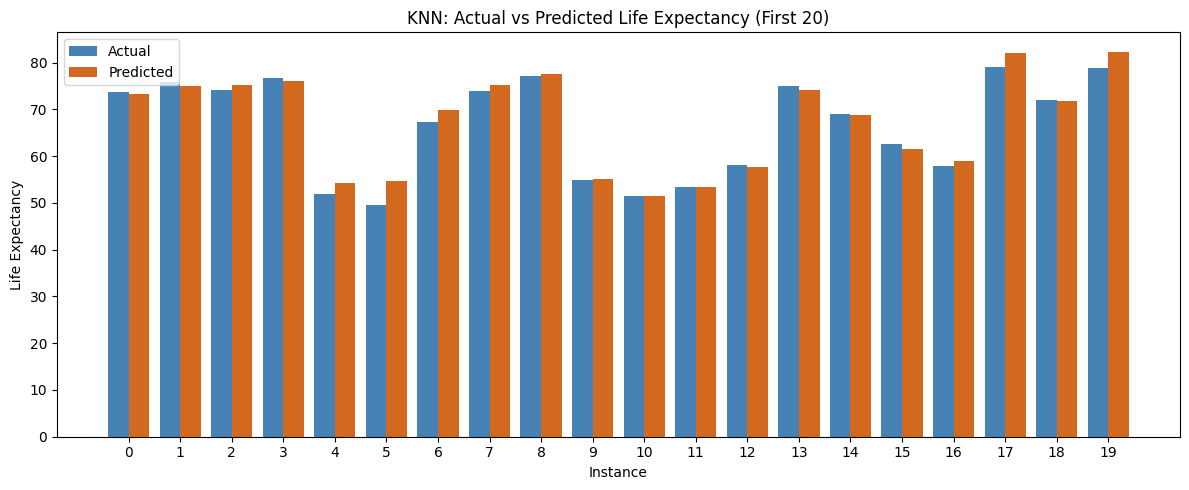

In [ ]:
# Plot predicted vs actual
plt.figure(figsize=(12, 5))
x_range = np.arange(20)
plt.bar(x_range - 0.2, y_test.values[:20], width=0.4, label='Actual', color='steelblue')
plt.bar(x_range + 0.2, y_pred9[:20], width=0.4, label='Predicted', color='chocolate')
plt.title('KNN: Actual vs Predicted Life Expectancy (First 20)')
plt.xlabel('Instance')
plt.ylabel('Life Expectancy')
plt.xticks(x_axis)
plt.legend()
plt.tight_layout()
plt.show()

**Compairson**

In [ ]:
labels3 = ["LR", "EN", "KNN"]

r_before = [r2_score(y_test, y_pred7_before), r2_score(y_test, y_pred8_before), r2_score(y_test, y_pred9_before)]
r = [r2_score(y_test, y_pred7), r2_score(y_test, y_pred8), r2_score(y_test, y_pred9)]

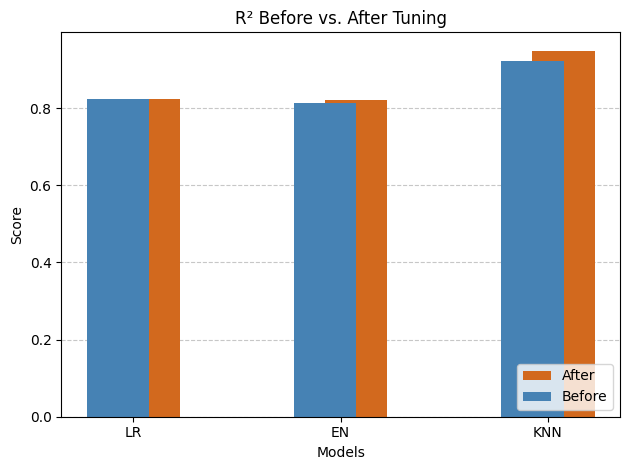

In [ ]:
x = np.arange(len(labels3))
width = 0.15

plt.bar(x + width/2, r, width*2, label='After', color='chocolate')
plt.bar(x - width/2, r_before, width*2, label='Before', color='steelblue')
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('R² Before vs. After Tuning')
plt.xticks(x, labels3)
plt.legend(loc="lower right")
plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()